In [1]:
from data_loader import SegmentationDataset, SegmentationDataModule
from evaluation_functions import compute_miou
from perturbation_methods import *
import torch

In [2]:
# Load dataset

# ESA-PhiLab-Edge/OEOBench-Burnt_Area_Dataset dataset
root_dir = '/local/s3167445/data'
dm = SegmentationDataModule(root_dir, batch_size=2, num_workers=4, transform=None)
dm.setup(stage='test')  # load test dataset

# Detect input channels dynamically
sample_img, _ = dm.test_dataset[0]#val_dataset[0]
in_ch = sample_img.shape[0]  # CHW format
print("Detected input channels:", in_ch)


Detected input channels: 7


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

from torch.utils.data import DataLoader

temp_ds = dm.test_dataset
temp_loader = DataLoader(temp_ds, batch_size=2, num_workers=4)




cuda


In [2]:
def get_predictions_multi(models, dataloader, device="cpu"):
    """
    models: dict -> {"name": model}
    returns:
        preds_dict: {"name": tensor of predictions}
        confs_dict: {"name": tensor of confidences}
        labels: ground truth tensor
    """
    preds_dict = {name: [] for name in models}
    confs_dict = {name: [] for name in models}
    labels_all = []

    # Set all models to eval
    for model in models.values():
        model.eval()

    with torch.no_grad():
        for x, y in dataloader:
            x = x.float().to(device)

            if y.ndim == 4:
                y = torch.argmax(y, dim=1)
            y = y.long().to(device)

            labels_all.append(y.cpu())

            for name, model in models.items():
                logits = model(x)

                # Convert to probabilities
                probs = torch.softmax(logits, dim=1)

                # Get confidence + prediction
                confs, preds = torch.max(probs, dim=1)

                preds_dict[name].append(preds.cpu())
                confs_dict[name].append(confs.cpu())

    if len(labels_all) == 0:
        raise ValueError("Dataloader produced no batches!")

    # Concatenate everything
    preds_dict = {
        name: torch.cat(preds_list)
        for name, preds_list in preds_dict.items()
    }

    confs_dict = {
        name: torch.cat(confs_list)
        for name, confs_list in confs_dict.items()
    }

    labels = torch.cat(labels_all)

    return preds_dict, confs_dict, labels

In [5]:
from my_models.my_baseline_models import *
pynas = torch.jit.load('my_models/PNAS_NVIDIA_jetson_AGX_orin.pt', map_location=device)
pynas.to(device)
pynas.eval()

resnet = ResNet18UNet(in_channels=7, num_classes=4) 
resnet.to(device)  
resnet.eval()
state_dict = torch.load("my_models/not_pretrained_resnet.pt", map_location=device)
resnet.load_state_dict(state_dict)#, strict=False)

efficientnet = EfficientNetB0UNet(in_channels=7, num_classes=4) 
efficientnet.to(device)  
efficientnet.eval()
state_dict = torch.load("my_models/efficientnetb0_30epochs_no_pretrain_FINAL.pt", map_location=device)
efficientnet.load_state_dict(state_dict)#, strict=False)

mobileone = MobileOneS0UNet(in_channels=7, num_classes=4) 
mobileone.to(device)  
mobileone.eval()
state_dict = torch.load("my_models/mobileone_s0_30epochs_no_pretrain_FINAL.pt", map_location=device)
mobileone.load_state_dict(state_dict)#, strict=False)



/local/s3167445/msc_venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

In [6]:
band_means = []  # length = C
num_bands = temp_ds[0][0].shape[0]  # number of channels
for c in range(num_bands):
    values = []
    for images, _ in temp_loader:
        values.append(images[:, c, :, :].reshape(-1))
    band_means.append(torch.cat(values).mean())
    

In [7]:

def band_ablation_generator(dataloader, band_idx):
    for images, masks in dataloader:
        images_np = images.numpy().copy()

        # Zero out one band
        images_np[:, band_idx, :, :] = 0

        yield torch.from_numpy(images_np).float(), masks


def band_mask_generator(dataloader, band_idx):
    for images, masks in dataloader:
        images = images.clone()
        
        mask = torch.ones_like(images)
        mask[:, band_idx, :, :] = 0
        
        images = images * mask
        
        yield images, masks

def band_mean_generator(dataloader, band_idx, band_means):
    for images, masks in dataloader:
        images = images.clone()
        images[:, band_idx, :, :] = band_means[band_idx]
        yield images, masks

import torch
import cv2
import numpy as np

def band_gaussian_blur_generator(dataloader, band_idx, ksize=5, sigma=1.0):
    """
    Apply Gaussian blur to one band per image.
    ksize: kernel size for blur
    sigma: standard deviation
    """
    for images, masks in dataloader:
        images = images.clone()
        B, C, H, W = images.shape

        for b in range(B):
            band = images[b, band_idx].cpu().numpy()
            blurred = cv2.GaussianBlur(band, (ksize, ksize), sigma)
            images[b, band_idx] = torch.from_numpy(blurred)

        yield images, masks


import numpy as np
from scipy.ndimage import gaussian_filter1d

def add_stripe_noise_chw(
    img,
    sigma_gain=0.05,
    sigma_bias=0.02,
    vertical_smooth=20,
    bad_column_prob=0.01,
    bad_column_scale=3.0,
    band_scaling=None,
    seed=None
):
    """
    Apply stripe noise to CHW image (C, H, W)

    Returns:
        noisy image (same shape)
    """
    if seed is not None:
        np.random.seed(seed)

    C, H, W = img.shape
    noisy = img.copy()

    if band_scaling is None:
        band_scaling = np.ones(C)

    for b in range(C):
        scale = band_scaling[b]

        # Gain & bias per column
        gain = np.random.normal(1.0, sigma_gain * scale, size=W)
        bias = np.random.normal(0.0, sigma_bias * scale, size=W)

        # Vertical correlated noise
        stripe_field = np.zeros((H, W))
        for c in range(W):
            col_noise = np.random.normal(0, 1, size=H)
            col_noise = gaussian_filter1d(col_noise, sigma=vertical_smooth)
            stripe_field[:, c] = col_noise

        stripe_field /= (np.std(stripe_field) + 1e-6)

        band = noisy[b]

        # Apply noise
        band = band * gain[None, :] + bias[None, :] + stripe_field * sigma_bias * scale

        # Bad columns
        num_bad = int(bad_column_prob * W)
        if num_bad > 0:
            bad_cols = np.random.choice(W, num_bad, replace=False)
            for c in bad_cols:
                band[:, c] += np.random.normal(0, sigma_bias * bad_column_scale * scale)

        noisy[b] = band

    return noisy

In [8]:
import numpy as np
import torch

def perturbed_generator(dataloader, optics):
    for images, masks in dataloader:
        images_np = images.numpy()             # (B, C, H, W)
        perturbed_images_np = np.zeros_like(images_np)

        for b in range(images_np.shape[0]):    
            img = images_np[b]                 # (C, H, W)

            # Blur blue channel
            ch = 2
            img[ch] = blur_channel_chw(img[ch], channel=ch, sigma=1.5)

            # Stripe noise (shared across bands)
            img = add_stripe_noise_chw_shared(
                img,
                sigma_gain=0.03,
                sigma_bias=0.02,
                vertical_smooth=15
            )

            # Apply SNR per channel 
            for c in range(img.shape[0]):
                perturbed_images_np[b, c] = optics.apply(img[c], normalize=True)

        yield torch.from_numpy(perturbed_images_np).float(), masks
        
import numpy as np
import torch
import cv2
from scipy.ndimage import gaussian_filter1d

def add_stripe_noise_chw_shared(
    img,
    sigma_gain=0.03,
    sigma_bias=0.02,
    vertical_smooth=15,
    band_scaling=None,
    seed=None
):
    """
    Stripe noise with shared structure on bands.
    """
    if seed is not None:
        np.random.seed(seed)

    C, H, W = img.shape
    noisy = img.copy()

    if band_scaling is None:
        band_scaling = np.ones(C)

    # Shared column-wise gain & bias
    gain = np.random.normal(1.0, sigma_gain, size=W)
    bias = np.random.normal(0.0, sigma_bias, size=W)

    # Shared vertical correlated noise
    stripe_field = np.zeros((H, W))
    for c in range(W):
        col_noise = np.random.normal(0, 1, size=H)
        col_noise = gaussian_filter1d(col_noise, sigma=vertical_smooth)
        stripe_field[:, c] = col_noise

    stripe_field /= (np.std(stripe_field) + 1e-6)

    # Apply per band
    for b in range(C):
        scale = band_scaling[b]
        band = noisy[b]

        band = (
            band * (1 + (gain - 1) * scale)
            + bias * scale
            + stripe_field * sigma_bias * scale
        )

        noisy[b] = band

    return noisy

from scipy.ndimage import gaussian_filter


def blur_channel_chw(img, channel=2, sigma=1.5):
    """
    Apply Gaussian blur to a single channel (CHW).
    """
    img = img.copy()
    img[channel] = gaussian_filter(img[channel], sigma=sigma)
    return img

def misalignment_generator_old(
    dataloader,
    processing_level="L1B",  
    rand_std=1.0,
    strength=1.0,
    interpolation=cv2.INTER_LINEAR
):

    for images, masks in dataloader:
        images_np = images.numpy()  # (B, C, H, W)
        B, C, H, W = images_np.shape

        perturbed = np.zeros_like(images_np)

        for b in range(B):

             
            if processing_level == "L1A":
                shifts = get_shifts_l1a(C)
            else:
                shifts = get_shifts_l1b(C, rand_std)

            shifts = shifts * strength  # control severity

            # Apply to all bands
            for c in range(C):
                dx, dy = shifts[c]

                M = np.array([
                    [1, 0, dx],
                    [0, 1, dy]
                ], dtype=np.float32)

                perturbed[b, c] = cv2.warpAffine(
                    images_np[b, c],
                    M,
                    dsize=(W, H),
                    flags=interpolation,
                    borderMode=cv2.BORDER_CONSTANT,
                    borderValue=0
                )

        yield torch.from_numpy(perturbed).float(), masks


def apply_custom_perturbations(batch):
    """
    batch: (images, labels)
    images: tensor (B, C, H, W)
    """
    imgs, labels = batch

    imgs_np = imgs.numpy() if hasattr(imgs, "numpy") else imgs
    perturbed_imgs = []

    for img in imgs_np:
        # Stripe noise 
        img = add_stripe_noise_chw_shared(
            img,
            sigma_gain=0.03,
            sigma_bias=0.02,
            vertical_smooth=15
        )

        # Blur blue channel (channel 2) 
        img = blur_channel_chw(img, channel=2, sigma=1.5)

        perturbed_imgs.append(img)

    perturbed_imgs = np.stack(perturbed_imgs)

    return perturbed_imgs, labels

def misalignment_generator(
    dataloader,
    processing_level="L1B",   # "L1A" or "L1B"
    rand_std=1.0,
    strength=1.0,
    image_interpolation=cv2.INTER_LINEAR,
    mask_interpolation=cv2.INTER_NEAREST
):
    for images, masks in dataloader:
        images_np = images.numpy()  # (B, C, H, W)
        B, C, H, W = images_np.shape
        mask_np = masks.numpy()
        
        perturbed_images = np.zeros_like(images_np)
        perturbed_masks = np.zeros_like(mask_np)  # assume (B, H, W) or (B,1,H,W)

        for b in range(B):

            # Generate shifts ONCE per image
            if processing_level == "L1A":
                shifts = get_shifts_l1a(C)
            else:
                shifts = get_shifts_l1b(C, rand_std)

            shifts = shifts * strength  # control severity

            # Apply shifts to all image bands
            for c in range(C):
                dx, dy = shifts[c]

                M = np.array([
                    [1, 0, dx],
                    [0, 1, dy]
                ], dtype=np.float32)

                perturbed_images[b, c] = cv2.warpAffine(
                    images_np[b, c],
                    M,
                    dsize=(W, H),
                    flags=image_interpolation,
                    borderMode=cv2.BORDER_CONSTANT,
                    borderValue=0
                )


            if mask_np.ndim == 3:
                mask_b = mask_np[b]           
            elif mask_np.ndim == 4:
                mask_b = mask_np[b, 0]        
            else:
                raise ValueError("Unexpected mask shape")

            # apply affine
            perturbed_masks[b] = cv2.warpAffine(
                mask_b,
                M,
                dsize=(W, H),
                flags=mask_interpolation,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0
            )

        yield torch.from_numpy(perturbed_images).float(), torch.from_numpy(perturbed_masks).long()

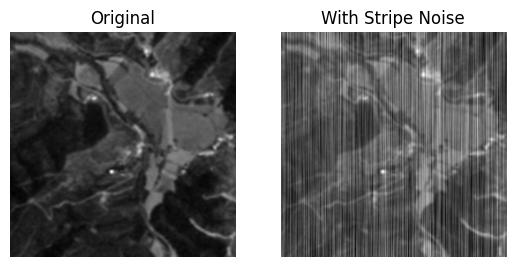

In [23]:
sample_img, _ = dm.test_dataset[0]  # (C, H, W)

# Convert to numpy if it's a tensor
img_np = sample_img

noisy_img = add_stripe_noise_chw(
    img_np,
    sigma_gain=0.03,
    sigma_bias=0.02,
    vertical_smooth=15,
    bad_column_prob=0.02,
    band_scaling=[1.0, 1.2, 0.8, 1.5, 1.0, 1.3, 1.1],
    seed=42
)

band_idx = 0
plt.figure()

plt.subplot(1, 2, 1)
plt.imshow(img_np[band_idx], cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_img[band_idx], cmap='gray')
plt.title("With Stripe Noise")
plt.axis("off")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import evaluation_functions
import importlib
importlib.reload(evaluation_functions)

from evaluation_functions import *


import warnings
warnings.filterwarnings("ignore")


# Models
models = {
    "PNAS": pynas,
    "ResNet": resnet,
    "mobilenet": efficientnet,
    "efficientnet": mobileone
}



results = {"SNR": []}
for name in models:
    results[f"{name}_mIoU"] = []
    results[f"{name}_consistency"] = []
    results[f"{name}_ICC"] = []
    results[f"{name}_ECE"] = []  
    results[f"{name}_confidence"] = []


print(results)

print("\n--- Computing Reference Predictions (No Noise) ---")

temp_ds = dm.test_dataset
temp_loader = DataLoader(temp_ds, batch_size=2, num_workers=4)

ref_preds_dict, ref_confs_dict, ref_labels = get_predictions_multi(models, temp_loader, device)


channel_to_blur = 2
# sigma_values = [0.5, 1.0, 2.0, 3.0]  # adjust as needed

SNR = 174
SNR_last = 1
SNR_levels = np.linspace(SNR, SNR_last, 10)
print(SNR_levels)
tgt_mtf=0.3
print(f"\n--- Starting SNR Evaluation ---")
for snr_val in SNR_levels:
    print(f"\nEvaluating SNR: {snr_val:.2f}")

    optics = OpticalSystem('sentinel', tgt_mtf, SNR=snr_val, l_ref=1.0)

    perturbed_data = list(perturbed_generator(temp_loader, optics))
    
    preds_dict, confs_dict, labels = get_predictions_multi(models, perturbed_data, device)
    
    #results["sigma"].append(sigma)
    results["SNR"].append(snr_val)
    for name in models:
        preds = preds_dict[name]
        ref_preds = ref_preds_dict[name]
        confs = confs_dict[name]

        # --- Metrics ---
        miou = compute_my_miou_from_preds(preds, labels, num_classes=4)
        consistency = prediction_consistency(ref_preds, preds)
        icc = compute_icc(ref_preds, preds)
        ece = compute_ece_from_preds_and_conf(preds, confs, labels)
        confidence = compute_confidence(confs)

        # --- Store ---
        results[f"{name}_mIoU"].append(miou)
        results[f"{name}_consistency"].append(consistency)
        results[f"{name}_ICC"].append(icc)
        results[f"{name}_ECE"].append(ece)
        results[f"{name}_confidence"].append(confidence)

        print(f"{name} -> mIoU: {miou:.4f}, Cons: {consistency:.4f}, ICC: {icc:.4f}, ECE: {ece:.4f}, Conf: {confidence:.4f}")

# -----------------------------
# Convert results to DataFrame
# -----------------------------
df_results = pd.DataFrame(results)
print(df_results)

{'SNR': [], 'PNAS_mIoU': [], 'PNAS_consistency': [], 'PNAS_ICC': [], 'PNAS_ECE': [], 'PNAS_confidence': [], 'ResNet_mIoU': [], 'ResNet_consistency': [], 'ResNet_ICC': [], 'ResNet_ECE': [], 'ResNet_confidence': [], 'mobilenet_mIoU': [], 'mobilenet_consistency': [], 'mobilenet_ICC': [], 'mobilenet_ECE': [], 'mobilenet_confidence': [], 'efficientnet_mIoU': [], 'efficientnet_consistency': [], 'efficientnet_ICC': [], 'efficientnet_ECE': [], 'efficientnet_confidence': []}

--- Computing Reference Predictions (No Noise) ---
[174.         154.77777778 135.55555556 116.33333333  97.11111111
  77.88888889  58.66666667  39.44444444  20.22222222   1.        ]

--- Starting Multi-SNR Evaluation ---

Evaluating SNR: 174.00
PNAS -> mIoU: 0.8555, Cons: 0.9827, ICC: 0.9679, ECE: 0.2086, Conf: 0.7077
ResNet -> mIoU: 0.8516, Cons: 0.9790, ICC: 0.9544, ECE: 0.1090, Conf: 0.8052
mobilenet -> mIoU: 0.5073, Cons: 0.7518, ICC: 0.4311, ECE: 0.0673, Conf: 0.7762
efficientnet -> mIoU: 0.6648, Cons: 0.8182, ICC: 

In [ ]:
print(df_results)
df_results.to_csv('bands_output.csv', index=False)  # index=False 

In [3]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import warnings
import importlib

from data_loader import SegmentationDataModule
from evaluation_functions import *
import evaluation_functions
importlib.reload(evaluation_functions)

warnings.filterwarnings("ignore")

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Baseline 7-channel ResNet
# -----------------------------
from my_models.my_baseline_models import *
resnet_7ch = ResNet18UNet(in_channels=7, num_classes=4)
resnet_7ch.to(device)
state_dict = torch.load("my_models/not_pretrained_resnet.pt", map_location=device)
resnet_7ch.load_state_dict(state_dict)
resnet_7ch.eval()

# Use full 7-channel dataset
dm_7ch = SegmentationDataModule(root_dir='/local/s3167445/data',
                                batch_size=2,
                                num_workers=4,
                                remove_channel=None)
dm_7ch.setup(stage='test')
loader_7ch = DataLoader(dm_7ch.test_dataset, batch_size=2, num_workers=4)

# Store results
results = {"Model": [], "mIoU": [], "Consistency": [], "ICC": [], "ECE": [], "Confidence": []}

print("\n--- Evaluating 7-channel Baseline ---")
preds_dict, confs_dict, labels = get_predictions_multi({"Baseline_7ch": resnet_7ch}, loader_7ch, device)
baseline_preds = preds_dict["Baseline_7ch"]  # for consistency metric

miou = compute_my_miou_from_preds(baseline_preds, labels, num_classes=4)
results["Model"].append("Baseline_7ch")
results["mIoU"].append(miou)
results["Consistency"].append(1.0)  # baseline vs itself
results["ICC"].append(compute_icc(baseline_preds, baseline_preds))
results["ECE"].append(compute_ece_from_preds_and_conf(baseline_preds, confs_dict["Baseline_7ch"], labels))
results["Confidence"].append(compute_confidence(confs_dict["Baseline_7ch"]))

print(f"Baseline_7ch -> mIoU: {miou:.4f}, Consistency: 1.0000")

# -----------------------------
# Evaluate each 6-channel model individually
# -----------------------------
model_paths = [
    "my_models/resnet_no_channel_0.pt",
    "my_models/resnet_no_channel_1.pt",
    "my_models/resnet_no_channel_2.pt",
    "my_models/resnet_no_channel_3.pt",
    "my_models/resnet_no_channel_4.pt",
    "my_models/resnet_no_channel_5.pt",
    "my_models/resnet_no_channel_6.pt"
]

for i, path in enumerate(model_paths):
    model_name = f"ResNet_NoChannel_{i}"

    # Create DataModule that removes the corresponding channel
    dm_6ch = SegmentationDataModule(root_dir='/local/s3167445/data',
                                    batch_size=2,
                                    num_workers=4,
                                    remove_channel=i)
    dm_6ch.setup(stage='test')
    loader_6ch = DataLoader(dm_6ch.test_dataset, batch_size=2, num_workers=4)

    # Load model with 6 channels
    model = ResNet18UNet(in_channels=6, num_classes=4)
    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    # Get predictions
    preds_dict, confs_dict, labels = get_predictions_multi({model_name: model}, loader_6ch, device)
    preds = preds_dict[model_name]
    confs = confs_dict[model_name]

    # Metrics
    miou = compute_my_miou_from_preds(preds, labels, num_classes=4)
    consistency = prediction_consistency(baseline_preds, preds)
    icc = compute_icc(baseline_preds, preds)
    ece = compute_ece_from_preds_and_conf(preds, confs, labels)
    confidence = compute_confidence(confs)

    results["Model"].append(model_name)
    results["mIoU"].append(miou)
    results["Consistency"].append(consistency)
    results["ICC"].append(icc)
    results["ECE"].append(ece)
    results["Confidence"].append(confidence)

    print(f"{model_name} -> mIoU: {miou:.4f}, Consistency: {consistency:.4f}, ICC: {icc:.4f}, ECE: {ece:.4f}, Confidence: {confidence:.4f}")

# -----------------------------
# Final results
# -----------------------------
df_results = pd.DataFrame(results)
print("\n--- Final Results ---")
print(df_results)


--- Evaluating 7-channel Baseline ---
Baseline_7ch -> mIoU: 0.8580, Consistency: 1.0000
ResNet_NoChannel_0 -> mIoU: 0.8516, Consistency: 0.9689, ICC: 0.9613, ECE: 0.1267, Confidence: 0.7873
ResNet_NoChannel_1 -> mIoU: 0.8775, Consistency: 0.9598, ICC: 0.9342, ECE: 0.1493, Confidence: 0.7803
ResNet_NoChannel_2 -> mIoU: 0.8392, Consistency: 0.9270, ICC: 0.8951, ECE: 0.1586, Confidence: 0.7487
ResNet_NoChannel_3 -> mIoU: 0.8768, Consistency: 0.9565, ICC: 0.9478, ECE: 0.1790, Confidence: 0.7499
ResNet_NoChannel_4 -> mIoU: 0.8744, Consistency: 0.9245, ICC: 0.8867, ECE: 0.1375, Confidence: 0.7901
ResNet_NoChannel_5 -> mIoU: 0.8444, Consistency: 0.9144, ICC: 0.9028, ECE: 0.1667, Confidence: 0.7405
ResNet_NoChannel_6 -> mIoU: 0.8758, Consistency: 0.9501, ICC: 0.9330, ECE: 0.1682, Confidence: 0.7604

--- Final Results ---
                Model      mIoU  Consistency       ICC       ECE  Confidence
0        Baseline_7ch  0.858020     1.000000  1.000000  0.127642    0.790533
1  ResNet_NoChannel_

In [7]:
df_results.to_csv('blackout.csv', index=False)

In [4]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np

# Assume dm_7ch is already created (full 7-channel test dataset)
loader_7ch = DataLoader(dm_7ch.test_dataset, batch_size=2, num_workers=4)

# Use baseline 7-channel ResNet
resnet_7ch.eval()
resnet_7ch.to(device)

results_ablation = {"Channel_BlackedOut": [], "mIoU": [], "Consistency": [], "ICC": [], "ECE": [], "Confidence": []}

# Get reference predictions on clean 7-channel data
ref_preds_dict, ref_confs_dict, labels = get_predictions_multi({"Baseline_7ch": resnet_7ch}, loader_7ch, device)
baseline_preds = ref_preds_dict["Baseline_7ch"]

num_channels = 7
print("\n--- Channel Ablation (Black-out 1 channel at a time) ---")
for ch in range(num_channels):
    preds_all = []
    confs_all = []
    
    # Iterate over dataset and black-out channel `ch`
    with torch.no_grad():
        for x, y in loader_7ch:
            x = x.float().to(device)
            y = y.long().to(device)
            
            # Black-out channel
            x[:, ch, :, :] = 0.0
            
            logits = resnet_7ch(x)
            probs = torch.softmax(logits, dim=1)
            confs, preds = torch.max(probs, dim=1)
            
            preds_all.append(preds.cpu())
            confs_all.append(confs.cpu())
    
    # Concatenate all predictions
    preds_all = torch.cat(preds_all)
    confs_all = torch.cat(confs_all)
    
    # Compute metrics
    miou = compute_my_miou_from_preds(preds_all, labels, num_classes=4)
    consistency = prediction_consistency(baseline_preds, preds_all)
    icc = compute_icc(baseline_preds, preds_all)
    ece = compute_ece_from_preds_and_conf(preds_all, confs_all, labels)
    confidence = compute_confidence(confs_all)
    
    results_ablation["Channel_BlackedOut"].append(ch)
    results_ablation["mIoU"].append(miou)
    results_ablation["Consistency"].append(consistency)
    results_ablation["ICC"].append(icc)
    results_ablation["ECE"].append(ece)
    results_ablation["Confidence"].append(confidence)
    
    print(f"Channel {ch} blacked-out -> mIoU: {miou:.4f}, Consistency: {consistency:.4f}, ICC: {icc:.4f}, ECE: {ece:.4f}, Confidence: {confidence:.4f}")

# Convert to DataFrame
df_ablation = pd.DataFrame(results_ablation)
print("\n--- Channel Ablation Results ---")
print(df_ablation)


--- Channel Ablation (Black-out 1 channel at a time) ---
Channel 0 blacked-out -> mIoU: 0.3384, Consistency: 0.6001, ICC: 0.5197, ECE: 0.2250, Confidence: 0.7533
Channel 1 blacked-out -> mIoU: 0.1950, Consistency: 0.4370, ICC: 0.1486, ECE: 0.3112, Confidence: 0.7668
Channel 2 blacked-out -> mIoU: 0.1094, Consistency: 0.4190, ICC: 0.0179, ECE: 0.5278, Confidence: 0.9552
Channel 3 blacked-out -> mIoU: 0.0631, Consistency: 0.1915, ICC: -0.2641, ECE: 0.7882, Confidence: 0.9883
Channel 4 blacked-out -> mIoU: 0.3970, Consistency: 0.5459, ICC: 0.4857, ECE: 0.1649, Confidence: 0.7094
Channel 5 blacked-out -> mIoU: 0.3306, Consistency: 0.5106, ICC: -0.0060, ECE: 0.2616, Confidence: 0.7448
Channel 6 blacked-out -> mIoU: 0.5128, Consistency: 0.6986, ICC: 0.6112, ECE: 0.1470, Confidence: 0.8586

--- Channel Ablation Results ---
   Channel_BlackedOut      mIoU  Consistency       ICC       ECE  Confidence
0                   0  0.338420     0.600066  0.519688  0.225001    0.753251
1                

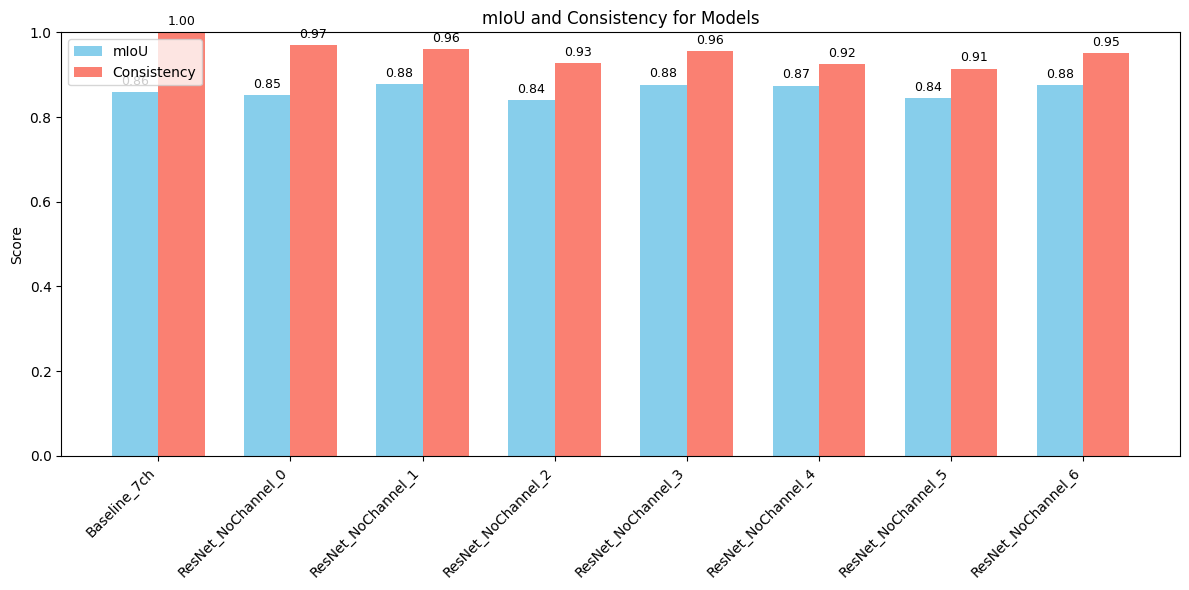

In [8]:
import matplotlib.pyplot as plt
import numpy as np

df_results = pd.read_csv('blackout.csv')

# Assume df_results is your DataFrame
models = df_results["Model"]
x = np.arange(len(models))  # label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12, 6))

# Bars
miou_bars = ax.bar(x - width/2, df_results["mIoU"], width, label='mIoU', color='skyblue')
consistency_bars = ax.bar(x + width/2, df_results["Consistency"], width, label='Consistency', color='salmon')

# Labels and ticks
ax.set_ylabel('Score')
ax.set_title('mIoU and Consistency for Models')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylim(0, 1)  # assuming both metrics are between 0 and 1
ax.legend()

# Annotate bars with values
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

annotate_bars(miou_bars)
annotate_bars(consistency_bars)

plt.tight_layout()
plt.show()